# Intro to Machine Learning: Logistic Regression (Logistic Linear Classifier)

| # | Function | Tested by | What it does |
|---|----------|-----------|--------------|
| 1 | `sigmoid` | `test_llc_obj` (1) | $\sigma(z) = 1/(1+e^{-z})$ |
| 2 | `nll_loss` | `test_llc_obj` (2) | Per-example negative log-likelihood, `(n, 1)` |
| 3 | `llc_obj` | `test_llc_obj` (3) | Mean NLL $+\ \lambda\lVert\theta\rVert^2$, a `float` |
| 4 | `d_sigmoid` | `test_llc_grad` (1) | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ |
| 5 | `d_nll_loss_th` | `test_llc_grad` (2) | Per-example $\partial \text{NLL}/\partial\theta$, `(d, n)` |
| 6 | `d_nll_loss_th0` | `test_llc_grad` (3) | Per-example $\partial \text{NLL}/\partial\theta_0$, `(1, n)` |
| 7 | `d_llc_obj_th` | `test_llc_grad` (4) | $\partial J/\partial\theta$, `(d, 1)` |
| 8 | `d_llc_obj_th0` | `test_llc_grad` (5) | $\partial J/\partial\theta_0$, `(1, 1)` |
| 9 | `llc_obj_grad` | `test_llc_grad` (6) | The two stacked, `(d+1, 1)` |
| 10 | `llc_min` | `test_llc_min` | Fits the classifier by gradient descent |
| 11 | `binary_loss` | `TestBinaryLoss` | 0-1 error rate |

Plus `gd` from gradient_descent, which `llc_min` builds on.

**Structure of each section:** the maths → the shape contract → the implementation → the
official test → a short interpretation. Diagnostics at the end: a full gradient check
against a numerical gradient, decision-boundary plots, and what $\lambda$ is actually doing.

### Data layout used throughout
`X` is **`(n, d)`** — one example per **row**. `y` is `(n, 1)` with labels in
$\{0, 1\}$ (**not** $\pm 1$ — that matters for every formula below). `th` is `(d, 1)`,
`th0` is `(1, 1)`.

In [2]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

import hw04_tests
importlib.reload(hw04_tests)          # picks up a freshly downloaded file
import hw04_tests as tests

from hw04_tests import rv, cv, super_simple_separable, separable_medium

np.set_printoptions(precision=6, suppress=False)
print("hw04_tests loaded. Test entry points:")
print([n for n in dir(tests) if n.startswith(("test_", "Test")) and n != "TestCase"])

hw04_tests loaded. Test entry points:
['TestBinaryLoss', 'test_llc_grad', 'test_llc_min', 'test_llc_obj']


In [3]:
# The two toy datasets the tests use. Note X is (n, d): one example per ROW.
X_ssep, Y_ssep = super_simple_separable()
X_med,  Y_med  = separable_medium()

for name, X, Y in [("super_simple_separable", X_ssep, Y_ssep),
                   ("separable_medium",      X_med,  Y_med)]:
    print(f"{name:<24} X {X.shape}  y {Y.shape}   labels={np.unique(Y)}")
    print("  X =", X.tolist(), " y =", Y.ravel().tolist())

super_simple_separable   X (4, 2)  y (4, 1)   labels=[0 1]
  X = [[2, 5], [3, 2], [9, 6], [12, 5]]  y = [1, 0, 1, 0]
separable_medium         X (4, 2)  y (4, 1)   labels=[0 1]
  X = [[2, -2], [-1, 2], [1, 2], [1, -1]]  y = [1, 0, 1, 0]


---
## 1. `sigmoid` — squashing a score into a probability

A linear classifier produces an unbounded score $z = x^\top\theta + \theta_0$. To read that
score as $P(y=1 \mid x)$ we need it in $(0, 1)$, which is what the **logistic / sigmoid**
function does:

$$\sigma(z) \;=\; \frac{1}{1 + e^{-z}}$$

Properties worth knowing by heart:

- $\sigma(0) = 0.5$ — so the decision boundary $z = 0$ is exactly the 50 % contour
- $\sigma(-z) = 1 - \sigma(z)$ — symmetric about $(0, 0.5)$
- $\sigma$ is strictly increasing, so **thresholding $\sigma(z)$ at $0.5$ is identical to
  thresholding $z$ at $0$** — the sigmoid changes the *loss*, never the predicted label
- $\sigma$ saturates: for $|z| \gtrsim 20$ it is numerically indistinguishable from 0 or 1

### Contract
The test calls `sigmoid(0.5).tolist()`, so the return value must be a NumPy object
(`np.float64` or an array), **not** a plain Python float. Writing `1/(1 + np.exp(-z))`
gives that for free, and it vectorises over arrays of any shape.

In [4]:
def sigmoid(z):
    """
    Logistic function, applied elementwise.

    z : scalar or array of any shape
    Returns the same shape. NumPy type (so .tolist() works, as the test requires).
    """
    return 1 / (1 + np.exp(-z))

In [5]:
print("sigmoid(0.5) =", sigmoid(0.5), " (expected 0.6224593312018546)")
print("sigmoid(0.0) =", sigmoid(0.0))
print("symmetry  sigmoid(-2) == 1 - sigmoid(2) ->", np.isclose(sigmoid(-2.0), 1 - sigmoid(2.0)))
print("saturation sigmoid([-30, -5, 0, 5, 30]) =", sigmoid(np.array([-30.0, -5, 0, 5, 30])))

sigmoid(0.5) = 0.6224593312018546  (expected 0.6224593312018546)
sigmoid(0.0) = 0.5
symmetry  sigmoid(-2) == 1 - sigmoid(2) -> True
saturation sigmoid([-30, -5, 0, 5, 30]) = [9.357623e-14 6.692851e-03 5.000000e-01 9.933071e-01 1.000000e+00]


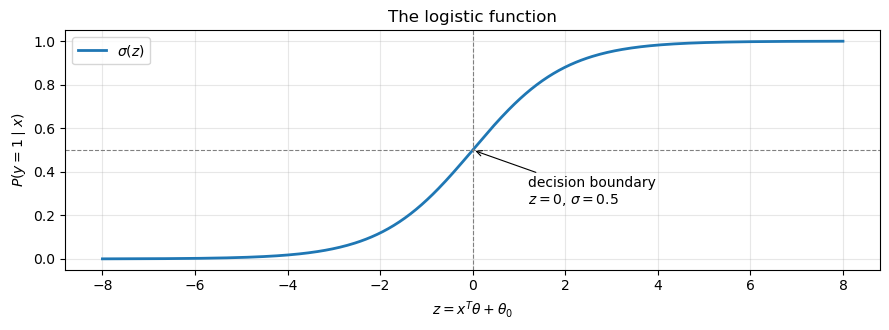

In [6]:
zs = np.linspace(-8, 8, 400)
plt.figure(figsize=(9, 3.4))
plt.plot(zs, sigmoid(zs), lw=2, label=r"$\sigma(z)$")
plt.axhline(0.5, color="gray", ls="--", lw=0.8)
plt.axvline(0.0, color="gray", ls="--", lw=0.8)
plt.annotate("decision boundary\n$z=0$, $\\sigma=0.5$", xy=(0, 0.5), xytext=(1.2, 0.25),
             arrowprops=dict(arrowstyle="->", lw=0.8))
plt.xlabel("$z = x^T\\theta + \\theta_0$"); plt.ylabel(r"$P(y=1\mid x)$")
plt.title("The logistic function"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

---
## 2. `nll_loss` — negative log-likelihood, per example

### Where the formula comes from
Treat the model output as a probability, $g_i = \sigma(x_i^\top\theta + \theta_0)$, and
assume each label is a Bernoulli draw with that parameter:

$$P(y_i \mid x_i) = g_i^{\,y_i}\,(1-g_i)^{\,1-y_i}$$

(one factor collapses to 1 depending on whether $y_i$ is 0 or 1). Maximising the likelihood
of the whole dataset is the same as minimising the **negative log**-likelihood, and the log
turns the product over examples into a sum:

$$\mathcal{L}_{\text{nll}}(g_i, y_i) \;=\; -\Big[\,y_i \log g_i \;+\; (1-y_i)\log(1-g_i)\Big]$$

Read it as a two-branch penalty: when $y_i = 1$ the loss is $-\log g_i$, when $y_i = 0$ it is
$-\log(1-g_i)$. Either way it is $0$ for a perfect confident prediction and $\to \infty$ for
a confident *wrong* one. **That unbounded penalty for confident mistakes is the whole point**
— it is why logistic regression is not fooled by a model that shrugs, and why squared error
is the wrong loss for classification.

### Contract
**Returns `(n, 1)` — the loss for each example separately, not the mean.** `llc_obj`
does the averaging in the next section. Since `X @ th + th0` is already `(n, 1)` and `y` is
`(n, 1)`, the expression is fully vectorised with no reshaping.

### Verify by hand (test case 2, example 0)
$x_0 = (2, 5)$, $\theta = (-0.40338351,\ 1.1849563)$, $\theta_0 = -2.26910091$:
$z_0 = 2(-0.40338) + 5(1.18496) - 2.26910 = 2.84891$, so $g_0 = \sigma(2.84891) = 0.94525$.
With $y_0 = 1$ the loss is $-\log(0.94525) = 0.05629$ ✓

In [7]:
def nll_loss(X, y, th, th0):
    """
    Per-example negative log-likelihood (log loss).

    X   : (n, d)      one example per row
    y   : (n, 1)      labels in {0, 1}
    th  : (d, 1)
    th0 : (1, 1)

    Returns (n, 1) -- the loss for EACH example, not the mean.
    """
    g = sigmoid(X @ th + th0)                             # (n, 1) predicted P(y=1|x)
    return -(y * np.log(g) + (1 - y) * np.log(1 - g))     # (n, 1)

In [8]:
# Hand-check of test case 2, example 0.
th1, th1_0 = np.array([[-0.40338351], [1.1849563]]), np.array([[-2.26910091]])
z = X_ssep @ th1 + th1_0
g = sigmoid(z)
losses = nll_loss(X_ssep, Y_ssep, th1, th1_0)

print(f"{'x':>10} {'y':>3} {'z':>10} {'g=P(y=1)':>10} {'nll':>10}")
for i in range(X_ssep.shape[0]):
    print(f"{str(X_ssep[i].tolist()):>10} {int(Y_ssep[i,0]):>3} "
          f"{z[i,0]:>10.5f} {g[i,0]:>10.5f} {losses[i,0]:>10.5f}")
print("\nshape:", losses.shape, "(must be (n, 1))")

         x   y          z   g=P(y=1)        nll
    [2, 5]   1    2.84891    0.94526    0.05629
    [3, 2]   0   -1.10934    0.24799    0.28501
    [9, 6]   1    1.21019    0.77033    0.26093
   [12, 5]   0   -1.18492    0.23417    0.26679

shape: (4, 1) (must be (n, 1))


The two branches of the loss, drawn. The left curve is the penalty when the true label is 1,
the right when it is 0 — each blows up as the model becomes confidently wrong.

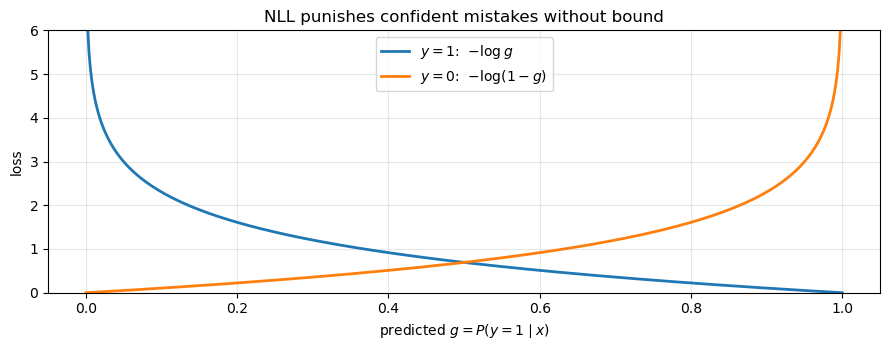

In [9]:
p = np.linspace(1e-4, 1 - 1e-4, 500)
plt.figure(figsize=(9, 3.6))
plt.plot(p, -np.log(p), lw=2, label=r"$y=1$:  $-\log g$")
plt.plot(p, -np.log(1 - p), lw=2, label=r"$y=0$:  $-\log(1-g)$")
plt.xlabel(r"predicted $g = P(y=1\mid x)$"); plt.ylabel("loss"); plt.ylim(0, 6)
plt.title("NLL punishes confident mistakes without bound")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

---
## 3. `llc_obj` — the regularised training objective

Average the per-example loss and add an $L_2$ penalty on $\theta$:

$$J(\theta, \theta_0) \;=\; \frac{1}{n}\sum_{i=1}^{n}\mathcal{L}_{\text{nll}}(g_i, y_i)
\;+\; \lambda\,\lVert\theta\rVert^2$$

### Why regularise here, and why not $\theta_0$?
On **separable** data the unregularised objective has **no finite minimiser**: take any
separator and scale $\theta \to c\theta$ with $c \to \infty$; every $g_i$ is pushed to 0 or 1
and the NLL goes to 0 without ever getting there. Gradient descent would just keep walking.
The $\lambda\lVert\theta\rVert^2$ term makes the problem strictly convex and *coercive*, so a
unique finite optimum exists. Section 10.2 demonstrates the runaway directly.

$\theta_0$ is deliberately **excluded** from the penalty. It only translates the boundary,
so shrinking it would bias the separator toward passing near the origin — an arbitrary
location that says nothing about model complexity. $\lVert\theta\rVert$, by contrast,
controls how *sharply* the sigmoid transitions, which is the thing worth constraining.

### Contract
Must return a **Python `float`** — the test checks `isinstance(ans, float)`, so a `(1, 1)`
array fails even with the right value. Use `np.linalg.norm(th) ** 2` for the penalty
(equivalently `np.sum(th ** 2)`).

In [10]:
def llc_obj(X, y, th, th0, lam):
    """
    Mean NLL plus L2 regularisation on th (NOT on th0).

    Returns a Python float, as the test asserts with isinstance(ans, float).
    """
    mean_nll = np.mean(nll_loss(X, y, th, th0))
    return float(mean_nll + lam * np.linalg.norm(th) ** 2)

In [11]:
tests.test_llc_obj(sigmoid, nll_loss, llc_obj)

Test 1 passed
Test 2 passed
Test 3 passed


In [12]:
# Decomposition of test case 3, so the 0.37394... is not a black box.
mean_nll = float(np.mean(nll_loss(X_ssep, Y_ssep, th1, th1_0)))
reg = 0.1 * float(np.linalg.norm(th1) ** 2)
J = llc_obj(X_ssep, Y_ssep, th1, th1_0, 0.1)
print(f"mean NLL          = {mean_nll!r}")
print(f"lam * ||th||^2    = {reg!r}   (lam=0.1, ||th||^2={float(np.sum(th1**2))!r})")
print(f"J                 = {J!r}")
print(f"expected            0.37394169100056684")
print(f"type(J) is float -> {isinstance(J, float)}")

mean NLL          = 0.21725772209560584
lam * ||th||^2    = 0.15668396890496103   (lam=0.1, ||th||^2=1.5668396890496104)
J                 = 0.37394169100056684
expected            0.37394169100056684
type(J) is float -> True


---
## 4. `d_sigmoid` — the derivative that makes everything else easy

$$\sigma'(z) = \frac{d}{dz}\left(1+e^{-z}\right)^{-1}
= \frac{e^{-z}}{\left(1+e^{-z}\right)^2}
= \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

The last step is the useful one: the derivative is expressible in terms of the **function
value**, so a forward pass that already computed $\sigma(z)$ gets its gradient for free —
one of the structural reasons the sigmoid became the default activation.

Its maximum is $\sigma'(0) = 0.25$ and it decays to 0 in both tails. That decay is the
**vanishing-gradient** problem: at $z = -23$ (test case 1) the derivative is
$1.03\times10^{-10}$, so a saturated unit learns essentially nothing.

### Contract
Elementwise, shape-preserving. The test passes a `(1, 2)` array and compares against a
`(1, 2)` answer.

In [ ]:
def d_sigmoid(z):
    """
    Derivative of the sigmoid, elementwise: sigma(z) * (1 - sigma(z)).

    Shape-preserving. Note it is written in terms of the FUNCTION VALUE, not z.
    """
    g = sigmoid(z)
    return g * (1 - g)

In [ ]:
z_probe = np.array([[71, -23.0]])
print("d_sigmoid([[71, -23]]) =", d_sigmoid(z_probe).tolist())
print("expected                [[0.0, 1.0261879629595766e-10]]")

# Confirm against a numerical derivative at a non-saturated point.
h = 1e-6
z0 = 0.7
print("\nanalytic  :", d_sigmoid(z0))
print("numerical :", (sigmoid(z0 + h) - sigmoid(z0 - h)) / (2 * h))
print("max of d_sigmoid is at z=0 ->", d_sigmoid(0.0))

In [ ]:
plt.figure(figsize=(9, 3.4))
plt.plot(zs, sigmoid(zs), lw=2, label=r"$\sigma(z)$")
plt.plot(zs, d_sigmoid(zs), lw=2, label=r"$\sigma'(z)=\sigma(1-\sigma)$")
plt.axhline(0.25, color="gray", ls="--", lw=0.8)
plt.text(-7.8, 0.27, r"max slope $0.25$ at $z=0$", fontsize=9)
plt.xlabel("$z$"); plt.title("Sigmoid and its derivative: gradients vanish in the tails")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

---
## 5. `d_nll_loss_th` and `d_nll_loss_th0` — per-example gradients

### The derivation (the one piece of calculus worth doing by hand)
With $g = \sigma(z)$ and $z = x^\top\theta + \theta_0$, apply the chain rule to
$\mathcal{L} = -[y\log g + (1-y)\log(1-g)]$:

$$\frac{\partial \mathcal{L}}{\partial g}
= -\frac{y}{g} + \frac{1-y}{1-g}
= \frac{g - y}{g(1-g)},
\qquad
\frac{\partial g}{\partial z} = g(1-g)$$

The $g(1-g)$ factors **cancel exactly**:

$$\boxed{\;\frac{\partial \mathcal{L}}{\partial z} \;=\; g - y\;}$$

The gradient is just the **prediction error**. Then, since $\partial z/\partial\theta = x$
and $\partial z/\partial\theta_0 = 1$:

$$\frac{\partial \mathcal{L}_i}{\partial \theta} = (g_i - y_i)\,x_i,
\qquad
\frac{\partial \mathcal{L}_i}{\partial \theta_0} = g_i - y_i$$

That cancellation is not a coincidence — it is why log loss is paired with the sigmoid. With
squared error instead, the $\sigma'(z)$ factor survives and multiplies every update by
$g(1-g)$, so a confidently-wrong saturated example produces a gradient of ~0 and the model
gets stuck. Log loss removes exactly that factor.

### Contract — mind the orientation
| Function | Shape | Built from |
|---|---|---|
| `d_nll_loss_th` | `(d, n)` — one **column** per example | `X.T * (g - y).T` |
| `d_nll_loss_th0` | `(1, n)` | `(g - y).T` |

`X.T` is `(d, n)` and `(g - y).T` is `(1, n)`, so the elementwise product broadcasts the
error across each example's feature column. Note this is `*`, **not** `@`.

### Verify by hand (test case 2, with $\theta=(-3,15)$, $\theta_0=2$)
Example 1 is $x = (3,2)$, $y = 0$, $z = -9 + 30 + 2 = 23$, so $g = \sigma(23) \approx 1 - 10^{-10}$
and $(g-y)x \approx (3, 2)$ — the expected `[2.9999999997, 1.9999999998]`. Examples 0 and 2
are confidently *correct* ($g \approx 1$, $y = 1$), so their gradient columns are zero.

In [ ]:
def d_nll_loss_th(X, y, th, th0):
    """
    Per-example gradient of the NLL with respect to th.

    Returns (d, n): column i is (g_i - y_i) * x_i.
    """
    g = sigmoid(X @ th + th0)          # (n, 1)
    return X.T * (g - y).T             # (d, n) * (1, n) broadcasts -> (d, n)


def d_nll_loss_th0(X, y, th, th0):
    """
    Per-example gradient of the NLL with respect to th0.

    Returns (1, n): entry i is (g_i - y_i).
    """
    g = sigmoid(X @ th + th0)          # (n, 1)
    return (g - y).T                   # (1, n)

In [ ]:
th2, th20 = np.array([[-3.0, 15.0]]).T, np.array([[2.0]])
g2 = sigmoid(X_ssep @ th2 + th20)

print(f"{'x':>10} {'y':>3} {'z':>7} {'g':>16} {'g-y':>16}")
for i in range(4):
    print(f"{str(X_ssep[i].tolist()):>10} {int(Y_ssep[i,0]):>3} "
          f"{(X_ssep[i] @ th2 + th20).item():>7.1f} {g2[i,0]:>16.12f} "
          f"{(g2[i,0] - Y_ssep[i,0]):>16.12f}")

print("\nd_nll_loss_th  shape", d_nll_loss_th(X_ssep, Y_ssep, th2, th20).shape, "= (d, n)")
print(d_nll_loss_th(X_ssep, Y_ssep, th2, th20))
print("\nd_nll_loss_th0 shape", d_nll_loss_th0(X_ssep, Y_ssep, th2, th20).shape, "= (1, n)")
print(d_nll_loss_th0(X_ssep, Y_ssep, th2, th20))
print("\nConfidently-correct examples (0 and 2) contribute nothing to the gradient.")

---
## 6. `d_llc_obj_th`, `d_llc_obj_th0`, `llc_obj_grad` — the objective's gradient

Average the per-example gradients over the dataset and add the derivative of the penalty,
$\partial(\lambda\lVert\theta\rVert^2)/\partial\theta = 2\lambda\theta$:

$$\frac{\partial J}{\partial \theta} = \frac{1}{n}\sum_{i=1}^{n}(g_i - y_i)\,x_i \;+\; 2\lambda\theta
\qquad\qquad
\frac{\partial J}{\partial \theta_0} = \frac{1}{n}\sum_{i=1}^{n}(g_i - y_i)$$

**No $2\lambda\theta_0$ term** in the second one — $\theta_0$ is not regularised, exactly
mirroring the objective in section 3. Getting this wrong is the single most common bug here,
and it is invisible at $\lambda = 0$.

### Contract
- `d_llc_obj_th` → `(d, 1)`: `np.mean(..., axis=1, keepdims=True)` over the `(d, n)` block.
  Drop `keepdims` and you get `(d,)`, which fails the shape assertion.
- `d_llc_obj_th0` → `(1, 1)`.
- `llc_obj_grad` → `(d+1, 1)`: `np.vstack` of the two, with $\theta_0$ **last**. That
  ordering is what `llc_min` relies on when it slices `w[:-1]` / `w[-1:]`.

### Verify by hand (test case 4)
Row means of the `(d, n)` block: $\frac{1}{4}(0+3+0+12) = 3.75$ and
$\frac{1}{4}(0+2+0+5) = 1.75$. Add $2(0.01)(-3, 15) = (-0.06, 0.30)$ → $(3.69, 2.05)$ ✓
And $\partial J/\partial\theta_0 = \frac{1}{4}(0+1+0+1) = 0.5$ ✓

In [ ]:
def d_llc_obj_th(X, y, th, th0, lam):
    """Gradient of the full objective w.r.t. th. Returns (d, 1)."""
    per_example = d_nll_loss_th(X, y, th, th0)                      # (d, n)
    return np.mean(per_example, axis=1, keepdims=True) + 2 * lam * th


def d_llc_obj_th0(X, y, th, th0, lam):
    """Gradient of the full objective w.r.t. th0. Returns (1, 1). NO regularisation term."""
    per_example = d_nll_loss_th0(X, y, th, th0)                     # (1, n)
    return np.mean(per_example, axis=1, keepdims=True)


def llc_obj_grad(X, y, th, th0, lam):
    """
    Full gradient stacked into one column vector, th0 LAST.

    Returns (d+1, 1) -- the layout llc_min's parameter vector uses.
    """
    return np.vstack([d_llc_obj_th(X, y, th, th0, lam),
                      d_llc_obj_th0(X, y, th, th0, lam)])

In [ ]:
tests.test_llc_grad(d_sigmoid, d_nll_loss_th, d_nll_loss_th0,
                    d_llc_obj_th, d_llc_obj_th0, llc_obj_grad)

In [ ]:
# Where the 3.69 / 2.05 / 0.5 come from.
block = d_nll_loss_th(X_ssep, Y_ssep, th2, th20)
print("row means of the (d, n) block :", np.mean(block, axis=1))
print("2 * lam * th  (lam=0.01)      :", (2 * 0.01 * th2).ravel())
print("d_llc_obj_th                  :", d_llc_obj_th(X_ssep, Y_ssep, th2, th20, 0.01).ravel())
print("d_llc_obj_th0                 :", d_llc_obj_th0(X_ssep, Y_ssep, th2, th20, 0.01).ravel())
print("\nllc_obj_grad shape", llc_obj_grad(X_ssep, Y_ssep, th2, th20, 0.01).shape, "= (d+1, 1)")

### Gradient check — always do this
An analytic gradient with a sign slip or a missing $1/n$ still *trains*; it just converges
to the wrong answer, silently. Comparing against a central-difference numerical gradient is
the cheapest way to catch it. Below, the whole `llc_obj_grad` is checked against `num_grad`
(the HW03 function) on random data at several $\lambda$ — agreement to $\sim 10^{-9}$ is the
expected signature of a correct derivation.

In [ ]:
def num_grad(f, delta=1e-5):
    """Central-difference numerical gradient (HW03), used here purely as a check."""
    def df(w):
        g = np.zeros(w.shape)
        for i in range(w.shape[0]):
            e = np.zeros(w.shape); e[i, 0] = delta
            g[i, 0] = float(np.squeeze((f(w + e) - f(w - e)) / (2 * delta)))
        return g
    return df


rng = np.random.default_rng(0)
X_chk = rng.normal(size=(12, 3))
y_chk = rng.integers(0, 2, size=(12, 1)).astype(float)
w_chk = rng.normal(size=(4, 1))          # [th (3); th0 (1)]

print(f"{'lam':>8} | {'max |analytic - numeric|':>26}")
print("-" * 38)
for lam in [0.0, 0.001, 0.05, 0.5]:
    f = lambda w: llc_obj(X_chk, y_chk, w[:-1, :], w[-1:, :], lam)
    analytic = llc_obj_grad(X_chk, y_chk, w_chk[:-1, :], w_chk[-1:, :], lam)
    numeric = num_grad(f)(w_chk)
    print(f"{lam:>8} | {np.max(np.abs(analytic - numeric)):>26.3e}")

print("\nSanity check that th0 is NOT regularised: the analytic gradient's last entry")
print("must be identical for every lam at a fixed w.")
last = [llc_obj_grad(X_chk, y_chk, w_chk[:-1, :], w_chk[-1:, :], l)[-1, 0]
        for l in [0.0, 0.001, 0.05, 0.5]]
print(" ", last, "-> all equal:", np.allclose(last, last[0]))

---
## 7. `llc_min` — fitting the classifier with gradient descent

Pack both parameters into one column vector $w = \begin{bmatrix}\theta \\ \theta_0\end{bmatrix}$
of shape `(d+1, 1)`, start from $w = \mathbf{0}$, and hand the objective and its gradient to
`gd`.

### The three conventions the reference values pin down
1. **Initialise at zeros**, `np.zeros((d+1, 1))`. Safe here because $J$ is strictly convex
   for $\lambda > 0$ — a single global optimum, so the start point affects only speed.
2. **Step size $\eta(i) = 2/\sqrt{i+1}$** — a decaying schedule. Large early steps cover
   ground; the $1/\sqrt{i}$ decay is the classic choice that lets the iterates settle.
3. **Exactly 10 iterations.** Unusually few, and deliberately so: on separable data with a
   tiny $\lambda$ the optimum is far out and slow to reach, so the reference answer is the
   state after 10 steps rather than a converged solution. Using 100 iterations gives a
   *better* classifier and a *failing* test.

### Contract
Returns `gd`'s tuple **`(w, J(w))`** — the test reads `ans[0]` as a `(d+1, 1)` array and
`ans[1]` as a scalar.

In [ ]:
def gd(f, df, x0, step_size_fn, max_iter):
    """
    Batch gradient descent (from HW03). Performs exactly max_iter updates.

    Returns (x, f(x)).
    """
    x = x0
    for t in range(max_iter):
        x = x - step_size_fn(t) * df(x)
    return x, f(x)


def llc_min(X, y, lam, max_iter=10):
    """
    Fit a logistic linear classifier by gradient descent.

    X   : (n, d)
    y   : (n, 1) labels in {0, 1}
    lam : L2 regularisation strength

    Returns (w, J(w)) where w is (d+1, 1) laid out as [th; th0].
    """
    d = X.shape[1]

    def f(w):
        return llc_obj(X, y, w[:-1, :], w[-1:, :], lam)

    def df(w):
        return llc_obj_grad(X, y, w[:-1, :], w[-1:, :], lam)

    w_init = np.zeros((d + 1, 1))
    return gd(f, df, w_init, lambda i: 2 / (i + 1) ** 0.5, max_iter)

In [ ]:
tests.test_llc_min(llc_min)

In [ ]:
for name, X, Y in [("super_simple_separable", X_ssep, Y_ssep),
                   ("separable_medium",      X_med,  Y_med)]:
    w, J = llc_min(X, Y, 0.0001)
    print(f"{name}")
    print(f"  th  = {w[:-1].ravel()}   th0 = {w[-1,0]:.10f}")
    print(f"  J   = {J!r}")

---
## 8. `binary_loss` — the metric you actually report

NLL is what we *optimise* (smooth and differentiable); the **0-1 loss** is what we *report*
— the fraction of examples whose predicted label is wrong:

$$\text{binary loss} = \frac{1}{n}\sum_{i=1}^{n}\mathbb{1}\!\left[\hat y_i \neq y_i\right]$$

It is piecewise constant, so its gradient is zero almost everywhere and it cannot be
minimised directly — which is the entire reason for the NLL surrogate.

### Contract — the reason for `axis=-1`
The test passes arrays of shape `(2, 1, n)`: two independent comparisons stacked, each
holding one `(1, n)` row of labels. The expected answer is `(2, 1)`. Averaging over the
**last** axis collapses `(2, 1, n) -> (2, 1)` exactly, and `keepdims=True` would give
`(2, 1, 1)` and fail the shape assertion. Using `axis=-1` rather than a hard-coded axis also
keeps the function working on a plain `(1, n)` pair of label rows.

In [ ]:
def binary_loss(Ypred, Y):
    """
    0-1 loss: the fraction of predictions that differ from the truth.

    Averages over the LAST axis, so (2, 1, n) -> (2, 1) and (1, n) -> (1,).
    No keepdims: the test compares against a (2, 1) array and checks the shape.
    """
    return np.mean(Ypred != Y, axis=-1)

In [ ]:
tests.TestBinaryLoss(binary_loss)

In [ ]:
# Using it the way you would in practice: fit, threshold at 0.5, score.
def predict(X, w):
    """Label predictions in {0, 1} from a packed parameter vector w = [th; th0]."""
    return (sigmoid(X @ w[:-1, :] + w[-1:, :]) > 0.5).astype(int)

for name, X, Y in [("super_simple_separable", X_ssep, Y_ssep),
                   ("separable_medium",      X_med,  Y_med)]:
    w, J = llc_min(X, Y, 0.0001)
    Yhat = predict(X, w)
    err = binary_loss(Yhat.T, Y.T)          # shape (1,)
    print(f"{name:<24} pred={Yhat.ravel()} true={Y.ravel()} "
          f"0-1 loss={err.item():.3f}  mean NLL={J:.5f}")

---
## 9. What the fitted classifier looks like

$w = [\theta; \theta_0]$ defines the boundary $\theta_1 x_1 + \theta_2 x_2 + \theta_0 = 0$,
a straight line in feature space. The shading is $\sigma(z)$ — note how the *steepness* of
the colour gradient, not the line's position, is what $\lVert\theta\rVert$ controls.

In [ ]:
def plot_llc(ax, X, Y, w, title):
    pad = 1.5
    x1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 250)
    x2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 250)
    G1, G2 = np.meshgrid(x1, x2)
    Z = sigmoid(w[0, 0] * G1 + w[1, 0] * G2 + w[2, 0])

    ax.contourf(G1, G2, Z, levels=25, cmap="RdBu", alpha=0.75, vmin=0, vmax=1)
    ax.contour(G1, G2, Z, levels=[0.5], colors="k", linewidths=2)
    pos, neg = Y.ravel() == 1, Y.ravel() == 0
    ax.scatter(X[pos, 0], X[pos, 1], c="darkblue", s=90, edgecolor="w", zorder=3, label="y=1")
    ax.scatter(X[neg, 0], X[neg, 1], c="darkred", s=90, edgecolor="w", marker="s",
               zorder=3, label="y=0")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title(title, fontsize=10)
    ax.legend(loc="best", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (name, X, Y) in zip(axes, [("super_simple_separable", X_ssep, Y_ssep),
                                   ("separable_medium", X_med, Y_med)]):
    w, J = llc_min(X, Y, 0.0001)
    plot_llc(ax, X, Y, w, f"{name}\n$\\lambda=10^{{-4}}$, 10 GD steps, $J={J:.4f}$")
plt.tight_layout(); plt.show()

---
## 10. Diagnostics

### 10.1 Convergence, and why 10 iterations is not convergence
`llc_min` hard-codes 10 steps to match the reference values. Tracking the objective over
many more steps shows it is still dropping steeply at step 10 — the returned answer is a
snapshot, not an optimum. Useful to know when the test passes but the classifier looks
mediocre.

In [ ]:
def llc_min_trace(X, y, lam, max_iter):
    """Same loop as llc_min, recording J at every iterate. Diagnostics only."""
    d = X.shape[1]
    f = lambda w: llc_obj(X, y, w[:-1, :], w[-1:, :], lam)
    df = lambda w: llc_obj_grad(X, y, w[:-1, :], w[-1:, :], lam)
    w = np.zeros((d + 1, 1))
    hist = [f(w)]
    for t in range(max_iter):
        w = w - (2 / (t + 1) ** 0.5) * df(w)
        hist.append(f(w))
    return w, np.array(hist)


with np.errstate(all="ignore"):
    _, h_ssep = llc_min_trace(X_ssep, Y_ssep, 1e-4, 400)
    _, h_med = llc_min_trace(X_med, Y_med, 1e-4, 400)

plt.figure(figsize=(9, 4))
plt.plot(h_ssep, lw=1.6, label="super_simple_separable")
plt.plot(h_med, lw=1.6, label="separable_medium")
plt.axvline(10, color="k", ls="--", lw=1)
plt.text(13, plt.ylim()[1] * 0.75, "what llc_min returns\n(iteration 10)", fontsize=9)
plt.xlabel("gradient descent step"); plt.ylabel(r"$J(w)$")
plt.title(r"Objective still falling at step 10 ($\lambda=10^{-4}$)")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

print(f"J at step 10  : {h_ssep[10]:.6f}   (this is the tested value)")
print(f"J at step 400 : {h_ssep[400]:.6f}")

### 10.2 The runaway: why $\lambda > 0$ is not optional
On separable data with $\lambda = 0$, the objective has **no finite minimiser**. Scaling
$\theta$ up pushes every $g_i$ toward 0 or 1, driving the NLL toward 0 asymptotically, so
$\lVert\theta\rVert$ grows without bound and gradient descent never stops. With
$\lambda > 0$ the penalty eventually overwhelms that gain and the norm settles.

In [ ]:
print(f"{'steps':>7} | {'lam=0: ||th||':>14} {'J':>11} | {'lam=0.01: ||th||':>17} {'J':>11}")
print("-" * 70)
for steps in [10, 50, 200, 1000, 5000, 20000]:
    with np.errstate(all="ignore"):
        w0, _ = llc_min(X_ssep, Y_ssep, 0.0, steps)
        j0 = llc_obj(X_ssep, Y_ssep, w0[:-1, :], w0[-1:, :], 0.0)
        wr, jr = llc_min(X_ssep, Y_ssep, 0.01, steps)
    print(f"{steps:>7} | {np.linalg.norm(w0[:-1]):>14.4f} {j0:>11.2e} | "
          f"{np.linalg.norm(wr[:-1]):>17.4f} {jr:>11.6f}")

print("\nlam=0 : J creeps toward 0 and ||th|| keeps growing - no optimum to reach.")
print("lam>0 : both settle. Note the intercept th0 also drifts without bound when lam=0,")
print("        since it is unregularised either way and rides along with theta.")

### 10.3 What $\lambda$ trades away
Larger $\lambda$ shrinks $\lVert\theta\rVert$, which flattens the sigmoid: predictions move
toward 0.5, so the model becomes *less confident* rather than differently oriented. The
regularised objective $J$ rises with $\lambda$ — which is why $\lambda$ must be chosen on
held-out data, never on training loss.

**But read the table carefully — it is not monotone, and that is instructive.** `llc_min`
runs only 10 steps with the fixed schedule $\eta(i) = 2/\sqrt{i+1}$, and the first step uses
$\eta = 2$. Once $\lambda$ is large the $2\lambda\theta$ term makes the gradient stiff, that
first step overshoots wildly, and 10 iterations is not enough to recover: at
$\lambda = 0.05$ and $\lambda = 0.3$ the run lands somewhere with $z$ far out on the
saturated side, a mean NLL in the single digits, and a 0-1 loss of 0.5 — *worse* than
guessing. The step-size schedule and $\lambda$ are not independent choices; a stable
optimiser for large $\lambda$ needs a smaller $\eta_0$ or more iterations.

In [ ]:
lams = [0.0, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.3]
print(f"{'lam':>8} | {'||th||':>9} | {'mean NLL':>10} | {'J':>10} | {'0-1 loss':>9} | g values")
print("-" * 88)
for lam in lams:
    with np.errstate(all="ignore"):
        w, J = llc_min(X_ssep, Y_ssep, lam, 10)
    g = sigmoid(X_ssep @ w[:-1, :] + w[-1:, :])
    mean_nll = float(np.mean(nll_loss(X_ssep, Y_ssep, w[:-1, :], w[-1:, :])))
    err = binary_loss(((g > 0.5).astype(int)).T, Y_ssep.T).item()
    print(f"{lam:>8} | {np.linalg.norm(w[:-1]):>9.4f} | {mean_nll:>10.5f} | "
          f"{J:>10.5f} | {err:>9.2f} | {np.round(g.ravel(), 3)}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, lam in zip(axes, [1e-4, 0.05, 0.3]):
    with np.errstate(all="ignore"):
        w, J = llc_min(X_ssep, Y_ssep, lam, 10)
    plot_llc(ax, X_ssep, Y_ssep, w,
             f"$\\lambda={lam}$   $\\|\\theta\\|={np.linalg.norm(w[:-1]):.2f}$")
fig.suptitle("Larger $\\lambda$ flattens the sigmoid: the model hedges rather than reorients",
             fontsize=11)
plt.tight_layout(); plt.show()

### 10.4 Numerical stability — the trap in `nll_loss`
`nll_loss` as written is the *mathematically* correct expression, and it is what the
reference values were generated from, so leave it alone for the graded answer. But be aware
of its two failure modes on real data:

- `np.exp(-z)` **overflows** for $z \lesssim -745$, emitting a warning (the result,
  $\sigma \to 0$, is still right).
- Worse, $\sigma(z)$ rounds to exactly $0.0$ or $1.0$ once $|z| \gtrsim 37$, and then
  `np.log(0)` gives $-\infty$: the loss becomes `inf` or `nan` and the whole fit dies —
  silently, if warnings are suppressed.

The standard fix is the **log-sum-exp** form, which never materialises the probability:
$-[y\log g + (1-y)\log(1-g)] = \log\!\left(1 + e^{-z}\right) + (1-y)\,z$, evaluated as
$\max(z,0) - yz + \log(1 + e^{-|z|})$. Same values, no overflow.

In [ ]:
def nll_loss_stable(X, y, th, th0):
    """Log-sum-exp form: mathematically identical, numerically safe for extreme z."""
    z = X @ th + th0
    return np.maximum(z, 0) - y * z + np.log1p(np.exp(-np.abs(z)))


th_big, th0_big = np.array([[-3.0], [15.0]]), np.array([[2.0]])
z_big = X_ssep @ th_big + th0_big
print("z values :", z_big.ravel(), "  labels:", Y_ssep.ravel())
print("sigmoid  :", sigmoid(z_big).ravel(), "<- saturated to exactly 1.0")
with np.errstate(all="ignore"):
    naive = nll_loss(X_ssep, Y_ssep, th_big, th0_big)
stable = nll_loss_stable(X_ssep, Y_ssep, th_big, th0_big)
print("\nnaive    :", naive.ravel())
print("stable   :", stable.ravel())
print("\nWhere g rounded to exactly 1.0 the naive form breaks two different ways:")
print("  y=1 (z=71, 65) -> 0 * log(0) = nan")
print("  y=0 (z=41)     -> -log(1 - 1) = inf")
print("The stable form returns the true values: ~0 for the correct confident ones,")
print("and 41.0 for the confidently-WRONG example (z=41, y=0) - the loss really is 41.")

print("\nAgreement in the normal range:",
      np.allclose(nll_loss(X_ssep, Y_ssep, th1, th1_0),
                  nll_loss_stable(X_ssep, Y_ssep, th1, th1_0)))

---
## 11. Full regression run

Re-runs every official test in one cell — the same check the autograder performs. Use this
after any edit.

In [ ]:
banner = lambda s: print("\n" + "=" * 64 + f"\n  {s}\n" + "=" * 64)

banner("test_llc_obj  (sigmoid, nll_loss, llc_obj)")
tests.test_llc_obj(sigmoid, nll_loss, llc_obj)

banner("test_llc_grad (d_sigmoid ... llc_obj_grad)")
tests.test_llc_grad(d_sigmoid, d_nll_loss_th, d_nll_loss_th0,
                    d_llc_obj_th, d_llc_obj_th0, llc_obj_grad)

banner("test_llc_min  (llc_min)")
tests.test_llc_min(llc_min)

banner("TestBinaryLoss (binary_loss)")
tests.TestBinaryLoss(binary_loss)

print("\n" + "=" * 64)
print("  Done - 12 checks total, every line above should read 'passed'")
print("=" * 64)

---
## 12. Reference card

```python
sigmoid(z)                            -> same shape   1/(1+exp(-z)), NumPy type not float
nll_loss(X, y, th, th0)               -> (n, 1)       PER-EXAMPLE, not the mean
llc_obj(X, y, th, th0, lam)           -> float        mean NLL + lam*||th||^2
d_sigmoid(z)                          -> same shape   sigma*(1-sigma)
d_nll_loss_th(X, y, th, th0)          -> (d, n)       X.T * (g-y).T   [ * not @ ]
d_nll_loss_th0(X, y, th, th0)         -> (1, n)       (g-y).T
d_llc_obj_th(X, y, th, th0, lam)      -> (d, 1)       row-mean + 2*lam*th
d_llc_obj_th0(X, y, th, th0, lam)     -> (1, 1)       row-mean, NO reg term
llc_obj_grad(X, y, th, th0, lam)      -> (d+1, 1)     vstack, th0 LAST
llc_min(X, y, lam)                    -> (w, J(w))    zeros init, 2/sqrt(i+1), 10 steps
binary_loss(Ypred, Y)                 -> mean over last axis, no keepdims
```

**The results worth remembering**

- $\sigma'(z) = \sigma(z)(1-\sigma(z))$ — the derivative from the function value
- $\partial \mathcal{L}_{\text{nll}}/\partial z = g - y$ — the $g(1-g)$ factors cancel, so
  the gradient is the plain prediction error. This cancellation is *why* log loss pairs with
  the sigmoid; with squared error the surviving $\sigma'$ factor stalls saturated examples.
- Thresholding $\sigma(z)$ at $0.5$ ≡ thresholding $z$ at $0$: the sigmoid changes the loss,
  never the predicted label
- On separable data, $\lambda = 0$ has **no** finite minimiser — $\lVert\theta\rVert \to \infty$

**The five mistakes that cause almost every failure here**

1. **Returning the mean from `nll_loss`.** It must be `(n, 1)`, per example; `llc_obj` averages.
2. **Regularising $\theta_0$.** No $2\lambda\theta_0$ in `d_llc_obj_th0`, no $\theta_0$ in
   `llc_obj`'s penalty. Invisible at $\lambda = 0$, wrong everywhere else.
3. **Wrong orientation.** `d_nll_loss_th` is `(d, n)` — *columns* are examples — and is built
   with elementwise `*`, not `@`. Dropping `keepdims=True` when averaging yields `(d,)`.
4. **Return type.** `llc_obj` must be a Python `float`; `sigmoid` must **not** be (the test
   calls `.tolist()` on it).
5. **Changing `llc_min`'s hyperparameters.** Zeros init, $\eta(i)=2/\sqrt{i+1}$, and exactly
   10 iterations. More iterations give a better classifier and a failing test.